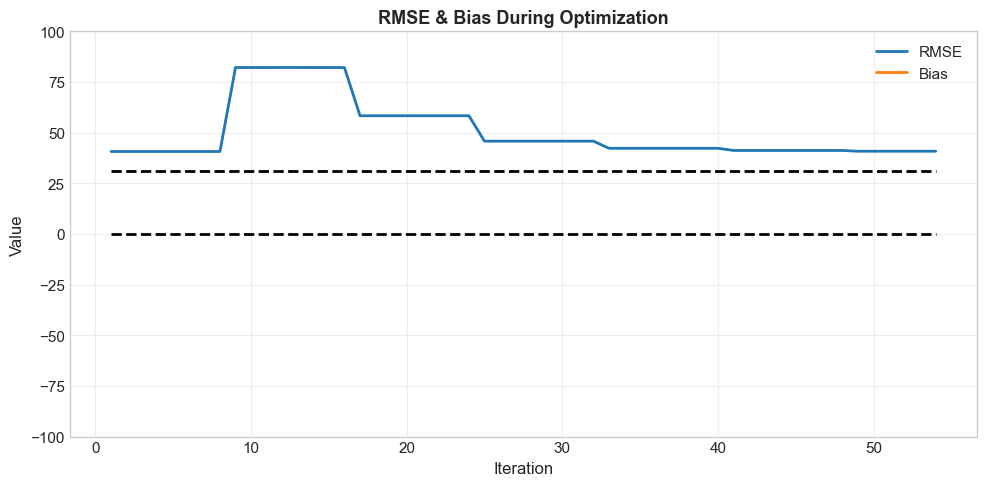

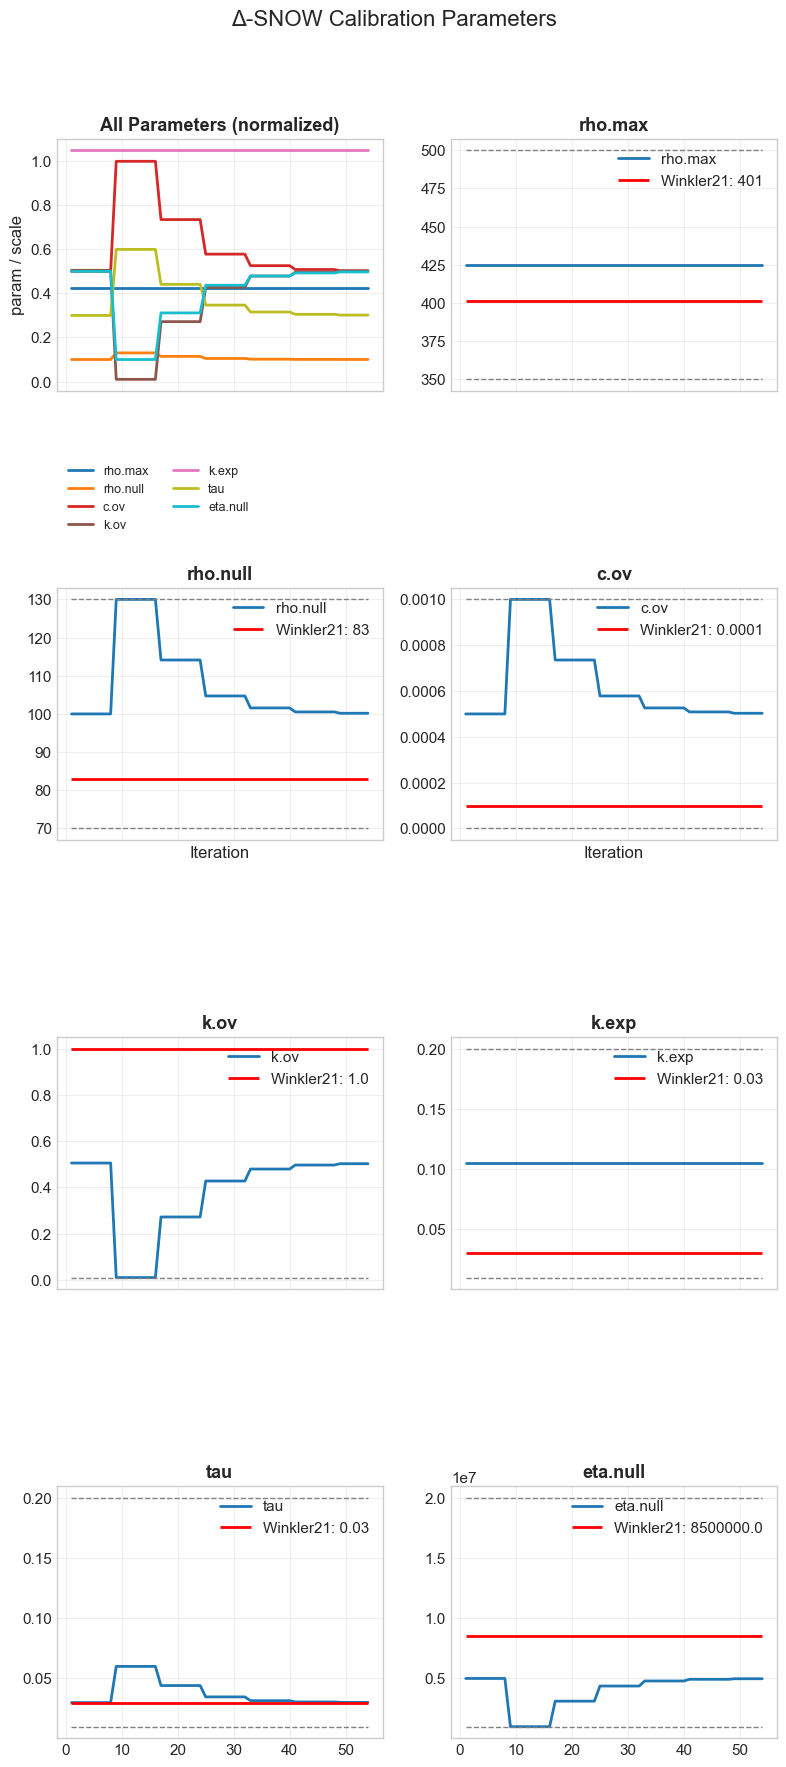

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Load calibration log ----
log_path = "/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_py/L-BFGS-B/python_calib_log/calibration_log.csv"
metrics = pd.read_csv(log_path)

# ---- Parameter configuration from your YAML ----
param_names = ["rho.max", "rho.null", "c.ov", "k.ov", "k.exp", "tau", "eta.null"]

bounds_unscaled = [
    [350, 500],       # rho.max
    [70, 130],        # rho.null
    [1e-9, 0.001],    # c.ov
    [0.01, 1],        # k.ov
    [0.01, 0.2],      # k.exp
    [0.01, 0.2],      # tau
    [1e6, 2e7]        # eta.null
]

scale_factors = [1000, 1000, 0.001, 1, 0.1, 0.1, 1e7]

# ---- Extract parameter columns ----
param_columns = metrics.columns[3:]
iters = metrics["iteration"]


# Sanity checks
assert list(param_columns) == param_names
assert len(param_columns) == len(bounds_unscaled) == len(scale_factors)

# ---- Normalize parameters (value / scale_factor) ----
norm_params = metrics[param_columns].copy()
for p, s in zip(param_columns, scale_factors):
    norm_params[p] = norm_params[p] / s

# ---- Style tweaks ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.titlesize": 16,
    "lines.linewidth": 2,
})

# ============================================================
# FIGURE 1 — Single plot: RMSE & Bias
# ============================================================
fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(iters, metrics["rmse"], label="RMSE")
ax1.plot(iters, metrics["bias"]* 10 , label="Bias") # scale bias to the same order of magnitude as the RSEM

ax1.set_title("RMSE & Bias During Optimization")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Value")
ax1.legend()
ax1.grid(alpha=0.3)
ax1.hlines( 0, xmin= iters[0], xmax= len(iters), colors= 'k', linestyles= '--')

ax1.set_ylim(-100, 100 )

# mark orignila error
ax1.hlines( 31.2, xmin= iters[0], xmax= len(iters), colors= 'k', linestyles= '--')


fig1.tight_layout()

# ============================================================
# FIGURE 2 — 2×4 subplots:
#   (0,0): all normalized params (no bounds)
#   others: each param unscaled + bounds
# ============================================================
fig2, axes = plt.subplots(4, 2, figsize=(8, 18), sharex=True)
axes = axes.reshape(4, 2)

# --------- Panel (0,0): all normalized parameters ----------
ax_all = axes[0, 0]
colors = plt.cm.tab10(np.linspace(0, 1, len(param_columns)))

for p, c in zip(param_columns, colors):
    ax_all.plot(iters, norm_params[p], label=p, color=c)

ax_all.set_title("All Parameters (normalized)")
ax_all.set_ylabel("param / scale")
ax_all.grid(alpha=0.3)
# Legend below the panel
ax_all.legend(fontsize=9, ncol=2, bbox_to_anchor=(0.0, -0.25), loc="upper left")

# --------- Remaining 7 panels: single params with bounds ----------
axes_flat = axes.flatten()
# axes_flat[0] is already used for "all params"
# --- Winkler et al. (2021) calibrated reference values ---
winkler_ref = {
    "rho.max": 401,        # kg/m³
    "rho.null": 83,        # kg/m³
    "c.ov": 1e-4,          # Pa⁻¹
    "k.ov": 1.0,           # [-]
    "k.exp": 0.030,        # m³/kg
    "tau": 0.03,           # m
    "eta.null": 8.5e6      # Pa·s
}

# --- integrate into your existing subplot loop ---
for i, p in enumerate(param_columns):
    ax = axes_flat[i + 1]  # start filling from second subplot
    lo, hi = bounds_unscaled[i]

    # plot optimizer evolution
    ax.plot(iters, metrics[p], label=p)

    # lower/upper bounds
    ax.hlines(lo, xmin=iters.min(), xmax=iters.max(),
              colors="gray", linestyles="dashed", linewidth=1)
    ax.hlines(hi, xmin=iters.min(), xmax=iters.max(),
              colors="gray", linestyles="dashed", linewidth=1)

    # ---- add Winkler et al. (2021) calibrated reference line ----
    if p in winkler_ref:
        ax.hlines(
            winkler_ref[p],
            xmin=iters.min(),
            xmax=iters.max(),
            colors="red",
            linestyles="solid",
            linewidth=2,
            label=f"Winkler21: {winkler_ref[p]}"
        )

    # styling
    ax.set_title(p)
    ax.legend(loc="best")
        
    

    ax.set_title(p)
    ax.grid(alpha=0.3)

# Set common x-label only on bottom row
for ax in axes[1, :]:
    ax.set_xlabel("Iteration")

fig2.suptitle("Δ-SNOW Calibration Parameters", y=0.98)
fig2.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()